# Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')


In [2]:
data = pd.read_csv('data_ver_3.csv',encoding='utf-8')

In [3]:
#Transform the data into a dataframe
df = pd.DataFrame(data)

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Species                   250 non-null    object 
 1   Condition_main            250 non-null    object 
 2   Compound                  250 non-null    object 
 3   BKT                       250 non-null    int64  
 4   PDS                       250 non-null    int64  
 5   crtZ                      250 non-null    int64  
 6   ZDS                       250 non-null    int64  
 7   crtW                      250 non-null    int64  
 8   crtB                      250 non-null    int64  
 9   lcyB                      250 non-null    int64  
 10  accB                      250 non-null    int64  
 11  FAD2                      250 non-null    int64  
 12  FAB2                      250 non-null    int64  
 13  fabD                      250 non-null    int64  
 14  accB_TPM  

In [5]:
df['Species'].value_counts()

Species
Haematococcus pluvialis       95
Chromochloris zofingiensis    92
Chlorella sorokiniana         32
Dunaliella salina             18
Chlamydomonas reinhardtii      9
Haematococcus lacustris        4
Name: count, dtype: int64

# Data Preparation

## 1.Handle Null data

In [6]:
#Check for missing values
print(df.isnull().sum())

Species                     0
Condition_main              0
Compound                    0
BKT                         0
PDS                         0
crtZ                        0
ZDS                         0
crtW                        0
crtB                        0
lcyB                        0
accB                        0
FAD2                        0
FAB2                        0
fabD                        0
accB_TPM                    0
BKT_TPM                     0
PDS_TPM                     0
crtZ_TPM                    0
ZDS_TPM                     0
crtW_TPM                    0
lcyB_TPM                    0
crtB_TPM                    0
FAD2_TPM                    0
FAB2_TPM                    0
fabD_TPM                    0
Carotenoid_Pathway_score    0
Fatty_Acid_Pathway_score    0
CombinedScore               0
Label                       0
dtype: int64


In [7]:
null_rows = df[df['Label'].isnull()]
print(null_rows)

Empty DataFrame
Columns: [Species, Condition_main, Compound, BKT, PDS, crtZ, ZDS, crtW, crtB, lcyB, accB, FAD2, FAB2, fabD, accB_TPM, BKT_TPM, PDS_TPM, crtZ_TPM, ZDS_TPM, crtW_TPM, lcyB_TPM, crtB_TPM, FAD2_TPM, FAB2_TPM, fabD_TPM, Carotenoid_Pathway_score, Fatty_Acid_Pathway_score, CombinedScore, Label]
Index: []

[0 rows x 29 columns]


In [8]:
# Drop rows with null values in the Label column
df = df.dropna(subset=['Label'])

In [9]:
print(df.isnull().sum())

Species                     0
Condition_main              0
Compound                    0
BKT                         0
PDS                         0
crtZ                        0
ZDS                         0
crtW                        0
crtB                        0
lcyB                        0
accB                        0
FAD2                        0
FAB2                        0
fabD                        0
accB_TPM                    0
BKT_TPM                     0
PDS_TPM                     0
crtZ_TPM                    0
ZDS_TPM                     0
crtW_TPM                    0
lcyB_TPM                    0
crtB_TPM                    0
FAD2_TPM                    0
FAB2_TPM                    0
fabD_TPM                    0
Carotenoid_Pathway_score    0
Fatty_Acid_Pathway_score    0
CombinedScore               0
Label                       0
dtype: int64


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Species                   250 non-null    object 
 1   Condition_main            250 non-null    object 
 2   Compound                  250 non-null    object 
 3   BKT                       250 non-null    int64  
 4   PDS                       250 non-null    int64  
 5   crtZ                      250 non-null    int64  
 6   ZDS                       250 non-null    int64  
 7   crtW                      250 non-null    int64  
 8   crtB                      250 non-null    int64  
 9   lcyB                      250 non-null    int64  
 10  accB                      250 non-null    int64  
 11  FAD2                      250 non-null    int64  
 12  FAB2                      250 non-null    int64  
 13  fabD                      250 non-null    int64  
 14  accB_TPM  

In [11]:
# Fill missing values in the Strain column with 'Unknown'
#df['Strain'] = df['Strain'].fillna('Unknown')
#print("Missing values in Strain:", df['Strain'].isnull().sum())

## 2.Cleaning data

In [12]:
#Cleaning categorical columns by removing newline characters and stripping whitespace
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].str.replace('\n', '', regex=False).str.strip()

In [13]:
df.head()

,Species,Condition_main,Compound,BKT,PDS,crtZ,ZDS,crtW,crtB,lcyB,...,crtW_TPM,lcyB_TPM,crtB_TPM,FAD2_TPM,FAB2_TPM,fabD_TPM,Carotenoid_Pathway_score,Fatty_Acid_Pathway_score,CombinedScore,Label
0,Haematococcus pluvialis,Chemical_treatment,astaxanthin,1,1,1,1,1,1,1,...,316.23,337.59,303.01,183.15,1312.55,416.57,0.487,0.413,-0.142,Medium
1,Haematococcus pluvialis,Chemical_treatment,astaxanthin,1,1,1,1,1,1,1,...,372.93,332.75,328.49,180.35,1346.96,463.89,0.507,0.440,0.414,Medium
2,Haematococcus pluvialis,Chemical_treatment,astaxanthin,1,1,1,1,1,1,1,...,304.01,236.36,229.38,182.97,945.75,325.69,0.465,0.404,-0.397,Medium
3,Haematococcus pluvialis,Chemical_treatment,astaxanthin,1,1,1,1,1,1,1,...,399.10,440.16,273.64,157.85,2345.84,706.01,0.495,0.487,1.175,High
4,Haematococcus pluvialis,Chemical_treatment,astaxanthin,1,1,1,1,1,1,1,...,313.18,371.56,302.07,200.04,1248.15,505.90,0.478,0.446,0.395,Medium


In [14]:
df.drop(['Carotenoid_Pathway_score', 'Fatty_Acid_Pathway_score', 'CombinedScore'], axis=1, inplace=True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Species         250 non-null    object 
 1   Condition_main  250 non-null    object 
 2   Compound        250 non-null    object 
 3   BKT             250 non-null    int64  
 4   PDS             250 non-null    int64  
 5   crtZ            250 non-null    int64  
 6   ZDS             250 non-null    int64  
 7   crtW            250 non-null    int64  
 8   crtB            250 non-null    int64  
 9   lcyB            250 non-null    int64  
 10  accB            250 non-null    int64  
 11  FAD2            250 non-null    int64  
 12  FAB2            250 non-null    int64  
 13  fabD            250 non-null    int64  
 14  accB_TPM        250 non-null    float64
 15  BKT_TPM         250 non-null    float64
 16  PDS_TPM         250 non-null    float64
 17  crtZ_TPM        250 non-null    flo

In [16]:
df['Condition_main'].value_counts()

Condition_main
Light                 102
Nitrogen               36
Carbon_source          32
Chemical_treatment     24
Control                16
Sulfur                 15
Genotype               12
Other                  10
Salt_Osmotic            3
Name: count, dtype: int64

# EDA

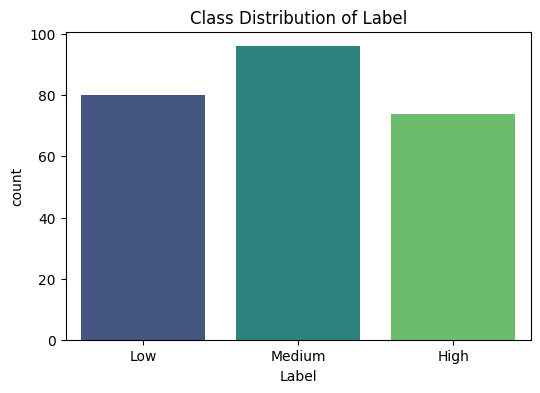

In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Label', order=['Low', 'Medium', 'High'],palette='viridis')
plt.title('Class Distribution of Label')
plt.show()

In [18]:
df['Label'].value_counts()

Label
Medium    96
Low       80
High      74
Name: count, dtype: int64

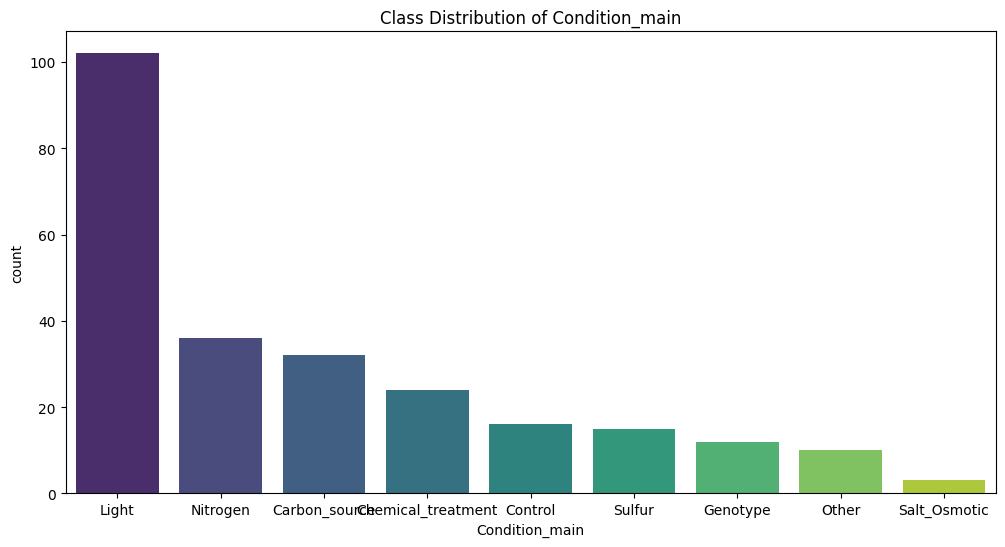

In [19]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Condition_main', order=['Light', 'Nitrogen', 'Carbon_source','Chemical_treatment','Control','Sulfur','Genotype','Other','Salt_Osmotic'],palette='viridis')
plt.title('Class Distribution of Condition_main')
plt.show()

พบยีนทั้งหมด 11 ตัว ได้แก่: ['accB_TPM', 'BKT_TPM', 'PDS_TPM', 'crtZ_TPM', 'ZDS_TPM', 'crtW_TPM', 'lcyB_TPM', 'crtB_TPM', 'FAD2_TPM', 'FAB2_TPM', 'fabD_TPM']


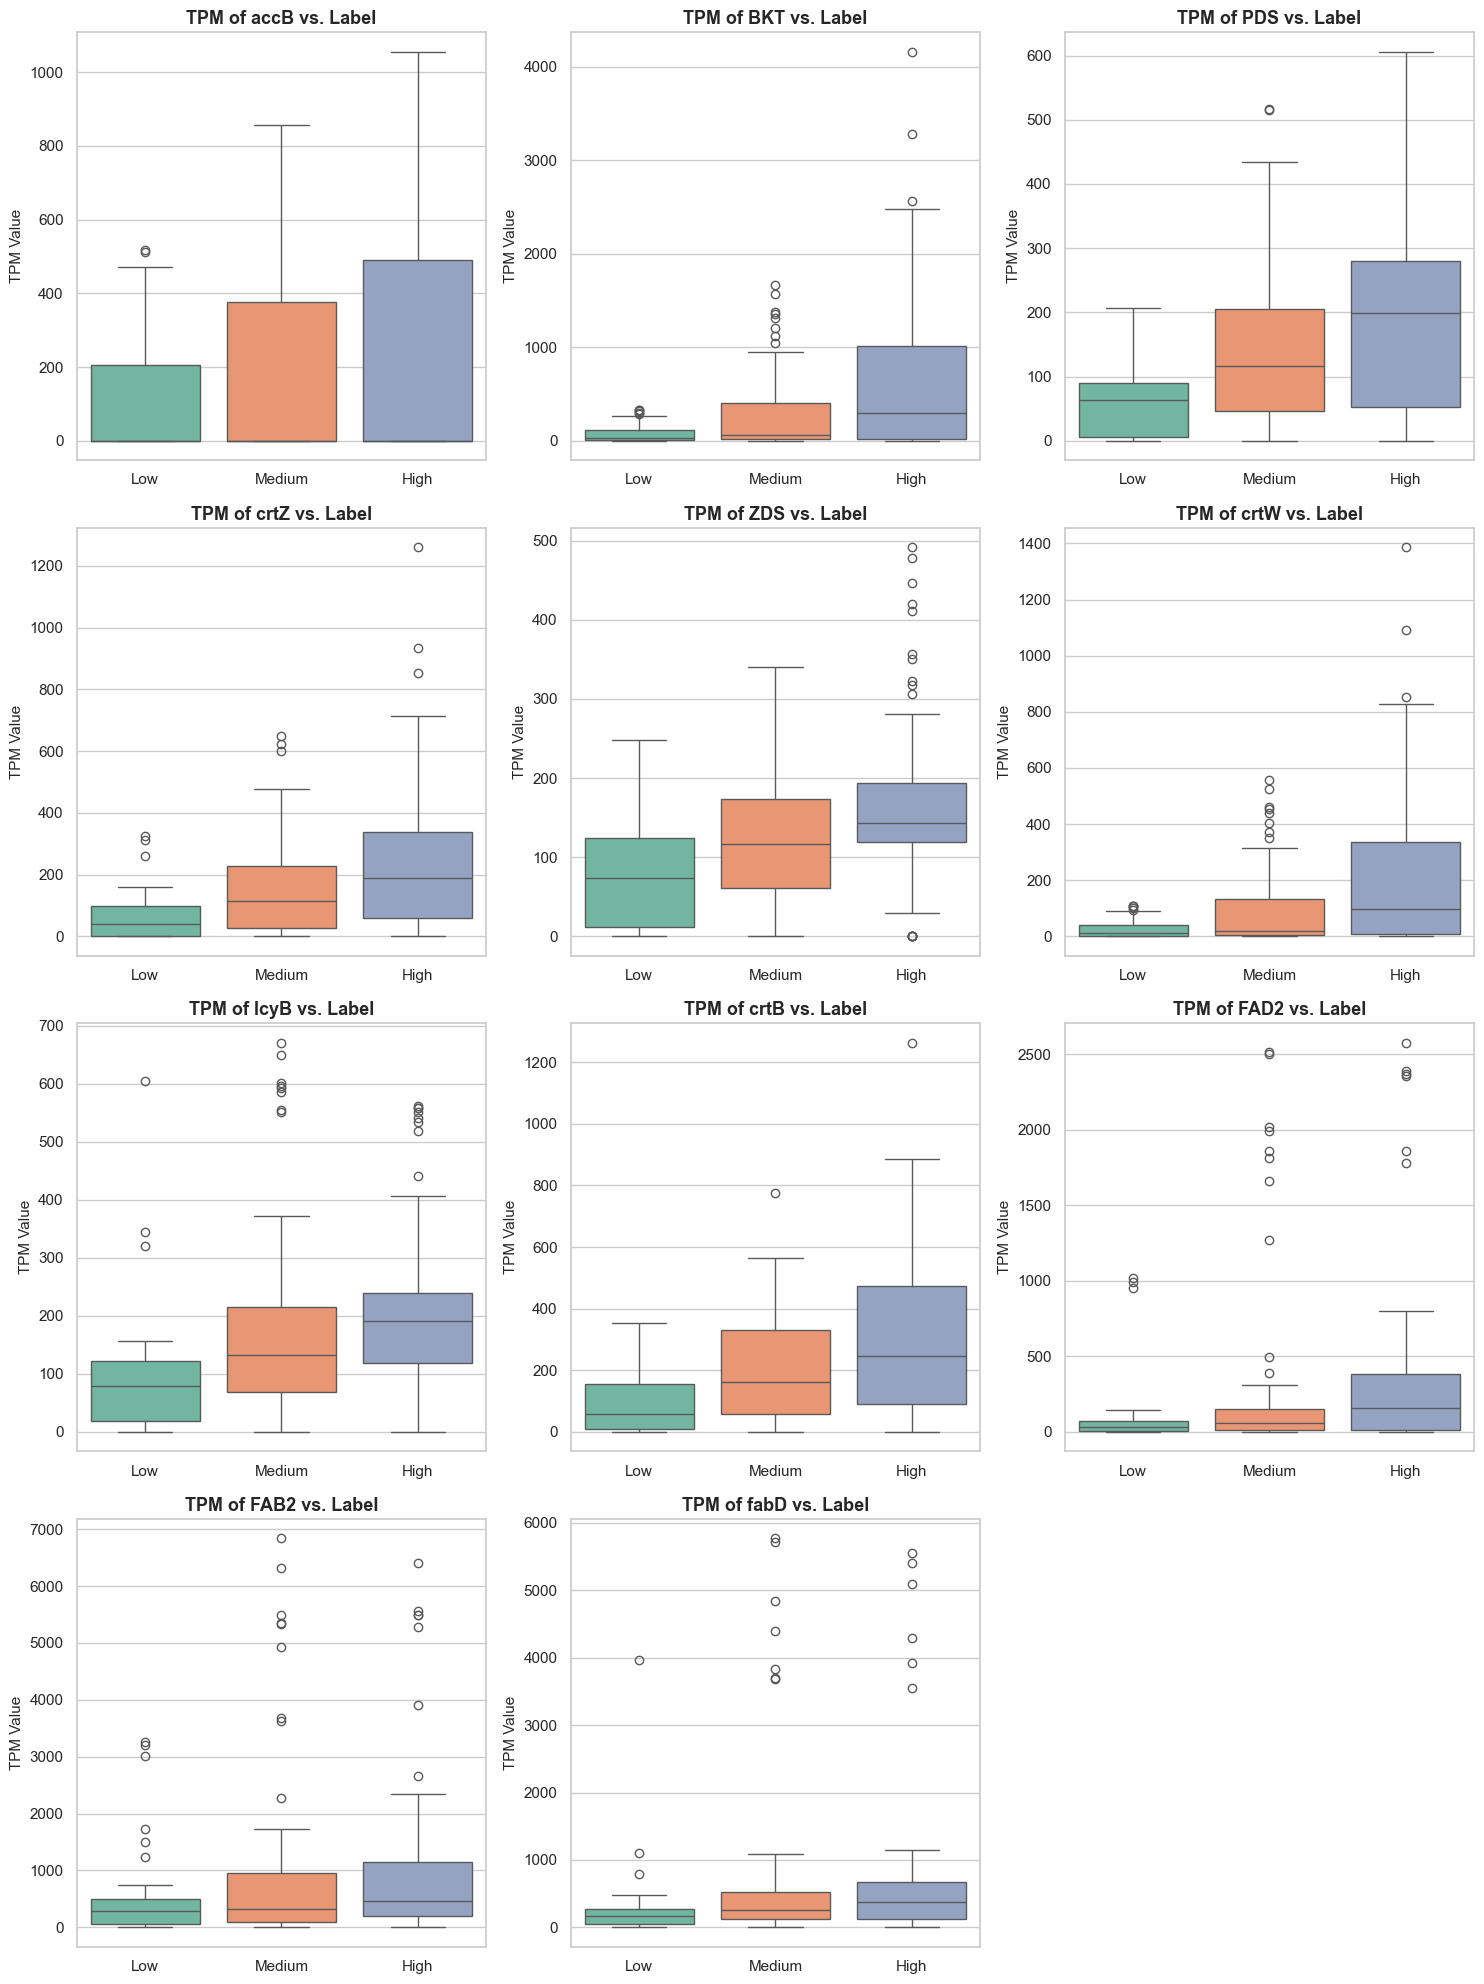

In [20]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

tpm_cols = [col for col in df.columns if '_TPM' in col]
num_genes = len(tpm_cols)

print(f"พบยีนทั้งหมด {num_genes} ตัว ได้แก่: {tpm_cols}")


cols_per_row = 3
rows = math.ceil(num_genes / cols_per_row)


fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, 5 * rows))

axes = axes.flatten()


for i, col_name in enumerate(tpm_cols):
    # วาด Boxplot ลงในช่องที่ i
    sns.boxplot(
        data=df, 
        x='Label', 
        y=col_name, 
        order=['Low', 'Medium', 'High'], 
        ax=axes[i], 
        palette='Set2' # เปลี่ยนสีได้ เช่น 'Set3', 'viridis', 'coolwarm'
    )
    
    # ตัดคำว่า '_TPM' ออกจากชื่อบนหัวกราฟเพื่อความสวยงาม
    gene_name = col_name.replace('_TPM', '')
    
    # ตั้งชื่อหัวกราฟและแกน Y
    axes[i].set_title(f'TPM of {gene_name} vs. Label', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('TPM Value', fontsize=11)
    axes[i].set_xlabel('')


for j in range(num_genes, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Heat Map shows relation between each gene expression

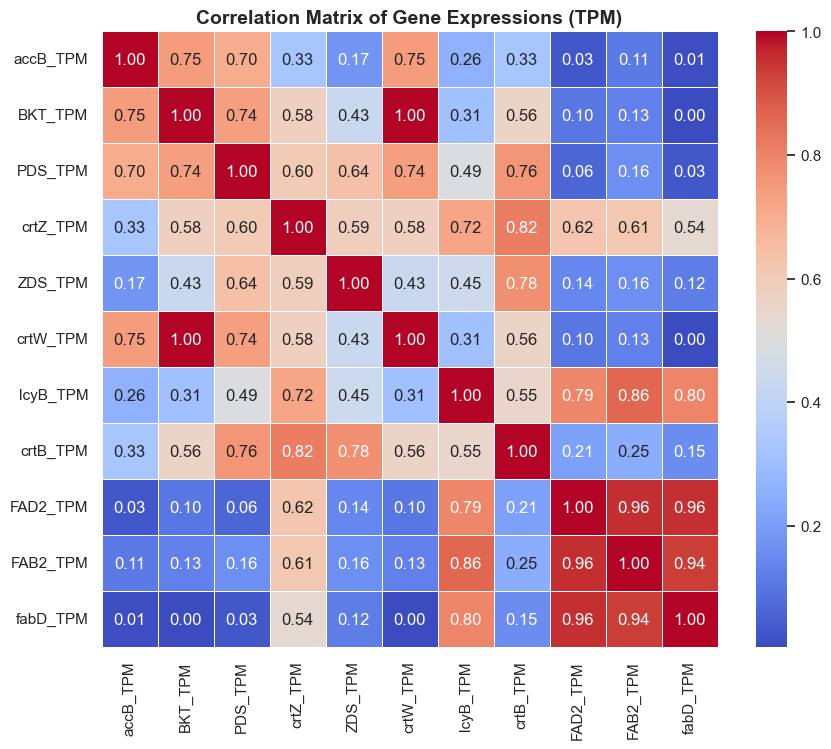

In [21]:
# เลือกเฉพาะคอลัมน์ที่ลงท้ายด้วย _TPM
tpm_cols = [col for col in df.columns if '_TPM' in col]

plt.figure(figsize=(10, 8))
corr_matrix = df[tpm_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix of Gene Expressions (TPM)', fontsize=14, fontweight='bold')
plt.show()

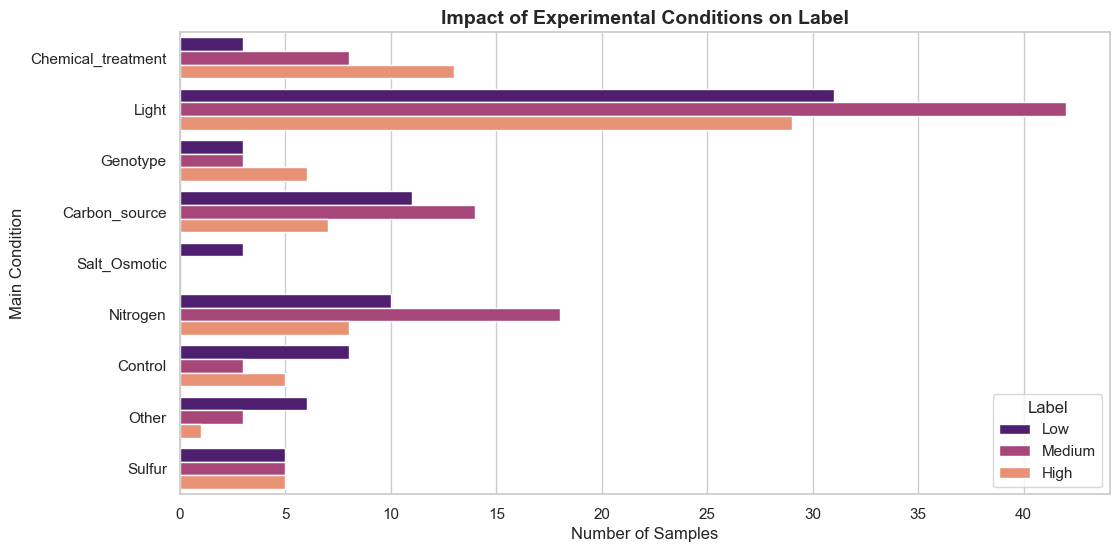

In [22]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Condition_main', hue='Label', hue_order=['Low', 'Medium', 'High'], palette='magma')
plt.title('Impact of Experimental Conditions on Label', fontsize=14, fontweight='bold')
plt.xlabel('Number of Samples')
plt.ylabel('Main Condition')
plt.legend(title='Label', loc='lower right')
plt.show()

# Data Preprocessing

## 1.Feature Selection

In [23]:
# Define the target column
target_col = 'Label'
# Delete unnecessary columns
#cols_to_drop = ['Strain']
#df = df.drop(columns=cols_to_drop)

X = df

In [24]:
#Drop corelated features
X = X.drop(['crtW_TPM','FAB2_TPM','fabD_TPM'], axis=1)

In [25]:
X.shape

(250, 23)

## 2.Seperate taget columns

In [26]:
#Separate X and Y
X = X.drop(columns=[target_col])
Y = df[target_col]

In [27]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Species         250 non-null    object 
 1   Condition_main  250 non-null    object 
 2   Compound        250 non-null    object 
 3   BKT             250 non-null    int64  
 4   PDS             250 non-null    int64  
 5   crtZ            250 non-null    int64  
 6   ZDS             250 non-null    int64  
 7   crtW            250 non-null    int64  
 8   crtB            250 non-null    int64  
 9   lcyB            250 non-null    int64  
 10  accB            250 non-null    int64  
 11  FAD2            250 non-null    int64  
 12  FAB2            250 non-null    int64  
 13  fabD            250 non-null    int64  
 14  accB_TPM        250 non-null    float64
 15  BKT_TPM         250 non-null    float64
 16  PDS_TPM         250 non-null    float64
 17  crtZ_TPM        250 non-null    flo

## 3. Encoding

### One-Hot Encoding

In [28]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [29]:
X_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   BKT                                 250 non-null    int64  
 1   PDS                                 250 non-null    int64  
 2   crtZ                                250 non-null    int64  
 3   ZDS                                 250 non-null    int64  
 4   crtW                                250 non-null    int64  
 5   crtB                                250 non-null    int64  
 6   lcyB                                250 non-null    int64  
 7   accB                                250 non-null    int64  
 8   FAD2                                250 non-null    int64  
 9   FAB2                                250 non-null    int64  
 10  fabD                                250 non-null    int64  
 11  accB_TPM                            250 non-n

### Label Encoder

In [30]:
# To change Label(High,Medium,Low) to numerical values (0,1,2)
label_encoder = LabelEncoder()
Y_encoded = label_encoder.fit_transform(Y)

print(f"Label classes: {label_encoder.classes_}")
print(f"Encoded labels: {np.unique(Y_encoded)}")

Label classes: ['High' 'Low' 'Medium']
Encoded labels: [0 1 2]


## 4.Train Test split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, Y_encoded, test_size=0.2, random_state=42, stratify=Y_encoded
)

## 5. Data scaling

In [32]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}, X_test shape: {X_test_scaled.shape}")

X_train shape: (200, 36), X_test shape: (50, 36)


# Model

## Import Model

In [33]:
# Model training for multiple classifiers: LogisticRegression, QDA, KNN, ANN, SVC, RandomForest, XGBoost
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC    # ->SVM
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score

# Keras / TensorFlow for ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

## Model Trainning

In [34]:
# reproducibility
np.random.seed(42)
tf.random.set_seed(42)


n_classes = len(np.unique(y_train))

results = {}

### Logistic Regression

In [35]:
# 1) Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=2000)
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
results['LogisticRegression'] = {
    'model': lr,
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True)
}

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Base logistic regression (multiclass)
lr = LogisticRegression(random_state=42)

# Parameter grid with solver-safe combinations
param_grid = [
    {
        'solver': ['lbfgs', 'newton-cg', 'sag'],
        'penalty': ['l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'multi_class': ['multinomial'],
        'max_iter': [1000]
    },
    {
        'solver': ['liblinear', 'saga'],
        'penalty': ['l1', 'l2'],
        'C': [0.001, 0.01, 0.1, 1, 10],
        'multi_class': ['ovr'],
        'max_iter': [1000]
    }
]

# Grid search
lr_grid = GridSearchCV(lr, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
lr_grid.fit(X_train_scaled, y_train)

best_lr = lr_grid.best_estimator_
print("Best params:", lr_grid.best_params_)
print("Best CV score:", lr_grid.best_score_)

# Test evaluation
y_pred = best_lr.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: cross-validated scores on training set
cv_scores = cross_val_score(best_lr, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Train CV scores:", cv_scores)
print("Train CV mean:", cv_scores.mean())
# ...existing code...

Fitting 5 folds for each of 38 candidates, totalling 190 fits
Best params: {'C': 100, 'max_iter': 1000, 'multi_class': 'multinomial', 'penalty': 'l2', 'solver': 'newton-cg'}
Best CV score: 0.7150000000000001
Test Accuracy: 0.6

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.53      0.57        15
           1       0.75      0.75      0.75        16
           2       0.48      0.53      0.50        19

    accuracy                           0.60        50
   macro avg       0.61      0.60      0.61        50
weighted avg       0.61      0.60      0.60        50

Confusion Matrix:
 [[ 8  0  7]
 [ 0 12  4]
 [ 5  4 10]]
Train CV scores: [0.75  0.725 0.725 0.75  0.625]
Train CV mean: 0.7150000000000001


### SVM

In [37]:
# 4) Support Vector Classifier
svc = SVC(kernel='rbf', probability=True, random_state=42)
svc.fit(X_train_scaled, y_train)
y_pred = svc.predict(X_test_scaled)
results['SVC'] = {
    'model': svc,
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True)
}


In [38]:
# ...existing code...
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define base SVC and hyperparameter grid
svc = SVC(probability=True, random_state=42)
param_grid = {
    'kernel': ['rbf', 'linear', 'poly'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001]
}

# Grid search with 5-fold CV
svc_grid = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
svc_grid.fit(X_train_scaled, y_train)

# Best estimator and CV score
best_svc = svc_grid.best_estimator_
print("Best params:", svc_grid.best_params_)
print("Best CV score:", svc_grid.best_score_)

# Evaluate on test set
y_pred = best_svc.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: cross-validated scores on training set
cv_scores = cross_val_score(best_svc, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Train CV scores:", cv_scores)
print("Train CV mean:", cv_scores.mean())
# ...existing code...

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best CV score: 0.7050000000000001
Test Accuracy: 0.62

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.53      0.59        15
           1       0.69      0.69      0.69        16
           2       0.55      0.63      0.59        19

    accuracy                           0.62        50
   macro avg       0.63      0.62      0.62        50
weighted avg       0.63      0.62      0.62        50

Confusion Matrix:
 [[ 8  1  6]
 [ 1 11  4]
 [ 3  4 12]]
Train CV scores: [0.775 0.7   0.725 0.725 0.6  ]
Train CV mean: 0.7050000000000001


### QDA

In [39]:
# 2) Quadratic Discriminant Analysis
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_scaled, y_train)
y_pred = qda.predict(X_test_scaled)
results['QDA'] = {
    'model': qda,
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True)
}

In [40]:
# ...existing code...
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Base QDA
qda = QuadraticDiscriminantAnalysis()

# Parameter grid (regularization + optional covariance storage / tolerance)
param_grid = {
    'reg_param': [0.0, 0.001, 0.01, 0.1, 0.5],
    'store_covariance': [False, True],
    'tol': [1e-4, 1e-3, 1e-2]
}

# Grid search with 5-fold CV
qda_grid = GridSearchCV(qda, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
qda_grid.fit(X_train_scaled, y_train)

best_qda = qda_grid.best_estimator_
print("Best params:", qda_grid.best_params_)
print("Best CV score:", qda_grid.best_score_)

# Evaluate on test set
y_pred = best_qda.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: cross-validated scores on training set
cv_scores = cross_val_score(best_qda, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Train CV scores:", cv_scores)
print("Train CV mean:", cv_scores.mean())

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'reg_param': 0.1, 'store_covariance': False, 'tol': 0.0001}
Best CV score: 0.5499999999999999
Test Accuracy: 0.42

Classification Report:
               precision    recall  f1-score   support

           0       0.34      0.67      0.45        15
           1       0.58      0.44      0.50        16
           2       0.44      0.21      0.29        19

    accuracy                           0.42        50
   macro avg       0.46      0.44      0.41        50
weighted avg       0.46      0.42      0.40        50

Confusion Matrix:
 [[10  2  3]
 [ 7  7  2]
 [12  3  4]]
Train CV scores: [0.575 0.475 0.55  0.625 0.525]
Train CV mean: 0.5499999999999999


### KNN

In [41]:
# 3) K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
results['KNN'] = {
    'model': knn,
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True)
}

In [42]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Base KNN
knn = KNeighborsClassifier()

# Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]  # 1 = Manhattan, 2 = Euclidean
}

# Grid search with 5-fold CV
knn_grid = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
knn_grid.fit(X_train_scaled, y_train)

best_knn = knn_grid.best_estimator_
print("Best params:", knn_grid.best_params_)
print("Best CV score:", knn_grid.best_score_)

# Evaluate on test set
y_pred = best_knn.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: cross-validated scores on training set
cv_scores = cross_val_score(best_knn, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Train CV scores:", cv_scores)
print("Train CV mean:", cv_scores.mean())

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'algorithm': 'auto', 'n_neighbors': 3, 'p': 2, 'weights': 'distance'}
Best CV score: 0.6900000000000001
Test Accuracy: 0.62

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.53      0.55        15
           1       0.76      0.81      0.79        16
           2       0.53      0.53      0.53        19

    accuracy                           0.62        50
   macro avg       0.62      0.62      0.62        50
weighted avg       0.62      0.62      0.62        50

Confusion Matrix:
 [[ 8  1  6]
 [ 0 13  3]
 [ 6  3 10]]
Train CV scores: [0.8   0.6   0.725 0.7   0.625]
Train CV mean: 0.6900000000000001


### Random Forest

In [43]:
# 5) Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)
results['RandomForest'] = {
    'model': rf,
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True)
}

In [44]:
# ...existing code...
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Base Random Forest
rf = RandomForestClassifier(random_state=42)

# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

# Grid search with 5-fold CV
rf_grid = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
rf_grid.fit(X_train_scaled, y_train)

best_rf = rf_grid.best_estimator_
print("Best params:", rf_grid.best_params_)
print("Best CV score:", rf_grid.best_score_)

# Evaluate on test set
y_pred = best_rf.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: cross-validated scores on training set
cv_scores = cross_val_score(best_rf, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Train CV scores:", cv_scores)
print("Train CV mean:", cv_scores.mean())
# ...existing code...

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Best params: {'bootstrap': False, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV score: 0.6950000000000001
Test Accuracy: 0.68

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.67      0.67        15
           1       0.76      0.81      0.79        16
           2       0.61      0.58      0.59        19

    accuracy                           0.68        50
   macro avg       0.68      0.69      0.68        50
weighted avg       0.68      0.68      0.68        50

Confusion Matrix:
 [[10  0  5]
 [ 1 13  2]
 [ 4  4 11]]
Train CV scores: [0.8   0.625 0.7   0.7   0.65 ]
Train CV mean: 0.6950000000000001


### XGBoost

In [45]:
# 6) XGBoost
xgb = XGBClassifier(n_estimators=200, random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1)
xgb.fit(X_train_scaled, y_train)
y_pred = xgb.predict(X_test_scaled)
results['XGBoost'] = {
    'model': xgb,
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True)
}

In [46]:
# ...existing code...
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Base XGBoost (multiclass)
xgb = XGBClassifier(objective='multi:softprob', use_label_encoder=False,
                    eval_metric='mlogloss', random_state=42, n_jobs=-1)

# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5],
    'min_child_weight': [1, 3, 5]
}

# Grid search with 5-fold CV
xgb_grid = GridSearchCV(xgb, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
xgb_grid.fit(X_train_scaled, y_train)

best_xgb = xgb_grid.best_estimator_
print("Best params:", xgb_grid.best_params_)
print("Best CV score:", xgb_grid.best_score_)

# Evaluate on test set
y_pred = best_xgb.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: cross-validated scores on training set
cv_scores = cross_val_score(best_xgb, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Train CV scores:", cv_scores)
print("Train CV mean:", cv_scores.mean())
# ...existing code...

Fitting 5 folds for each of 2187 candidates, totalling 10935 fits
Best params: {'colsample_bytree': 0.6, 'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.8}
Best CV score: 0.67
Test Accuracy: 0.62

Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.60      0.56        15
           1       0.78      0.88      0.82        16
           2       0.53      0.42      0.47        19

    accuracy                           0.62        50
   macro avg       0.61      0.63      0.62        50
weighted avg       0.61      0.62      0.61        50

Confusion Matrix:
 [[ 9  0  6]
 [ 1 14  1]
 [ 7  4  8]]
Train CV scores: [0.65  0.575 0.8   0.675 0.65 ]
Train CV mean: 0.67


### ANN

In [47]:
# 7) ANN (Keras)
# Use one-hot for training labels
y_train_cat = to_categorical(y_train, num_classes=n_classes)  #One-hot แล้วววววววววว
y_test_cat = to_categorical(y_test, num_classes=n_classes)

ann = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(n_classes, activation='softmax')
])
ann.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=0)
ann.fit(X_train_scaled, y_train_cat, validation_split=0.1, epochs=100, batch_size=32, callbacks=[es], verbose=0)

y_pred_proba = ann.predict(X_test_scaled)
y_pred = np.argmax(y_pred_proba, axis=1)
results['ANN'] = {
    'model': ann,
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True)
}

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


In [48]:
# ANN tuning with Keras Tuner (no scikit-learn GridSearchCV)
# Installs: pip install -U keras-tuner (run externally if needed)
try:
    import keras_tuner as kt
except Exception as e:
    raise ImportError("Please install keras-tuner: pip install -U keras-tuner")
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

def build_model(hp):
    units = hp.Choice('units', [64, 128])
    dropout = hp.Choice('dropout', [0.2, 0.3])
    lr = hp.Choice('learning_rate', [1e-3, 5e-4])
    model = keras.Sequential([
        keras.layers.Dense(units, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(max(32, units//2), activation='relu'),
        keras.layers.Dropout(dropout/2),
        keras.layers.Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Random search tuner (fast and simple)
tuner = kt.RandomSearch(build_model, objective='val_accuracy', max_trials=6,
                        executions_per_trial=1, directory='kt_dir', project_name='ann_tune')

es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
tuner.search(X_train_scaled, y_train, epochs=50, validation_split=0.1, callbacks=[es], verbose=1)

# Best hyperparameters and best validation (used here as CV proxy)
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_trials = tuner.oracle.get_best_trials(num_trials=1)
best_val = None
if best_trials:
    try:
        best_val = best_trials[0].metrics.get_last_value('val_accuracy')
    except Exception:
        best_val = None

print("Best params:", {
    'units': best_hps.get('units'),
    'dropout': best_hps.get('dropout'),
    'learning_rate': best_hps.get('learning_rate')
})
print("Best CV score:", best_val)

# Build and fit best model on full training set
best_model = tuner.hypermodel.build(best_hps)
best_model.fit(X_train_scaled, y_train, epochs=50, validation_split=0.1, callbacks=[es], verbose=0)

# Evaluate on test set
y_pred = np.argmax(best_model.predict(X_test_scaled), axis=1)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: manual cross-validated scores on training set (retrain per fold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
for train_idx, val_idx in skf.split(X_train_scaled, y_train):
    model = tuner.hypermodel.build(best_hps)
    model.fit(X_train_scaled[train_idx], y_train[train_idx], epochs=50,
              validation_data=(X_train_scaled[val_idx], y_train[val_idx]), callbacks=[es], verbose=0)
    preds = np.argmax(model.predict(X_train_scaled[val_idx]), axis=1)
    cv_scores.append(accuracy_score(y_train[val_idx], preds))

print("Train CV scores:", cv_scores)
print("Train CV mean:", np.mean(cv_scores))

Reloading Tuner from kt_dir\ann_tune\tuner0.json
Best params: {'units': 128, 'dropout': 0.2, 'learning_rate': 0.001}
Best CV score: 0.8571428656578064
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Test Accuracy: 0.56

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.47      0.50        15
           1       0.68      0.81      0.74        16
           2       0.44      0.42      0.43        19

    accuracy                           0.56        50
   macro avg       0.56      0.57      0.56        50
weighted avg       0.55      0.56      0.55        50

Confusion Matrix:
 [[ 7  1  7]
 [ 0 13  3]
 [ 6  5  8]]
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000267BE923D80> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function

## Model Result

### Best model

In [49]:
# Print summary sorted by accuracy
summary = {name: info['accuracy'] for name, info in results.items()}
for name, acc in sorted(summary.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {acc:.4f}")

# Example: detailed report for best model
best_name = max(summary, key=summary.get)
print(f"\nBest model: {best_name}\n")
import pprint
pprint.pprint(results[best_name]['report'])

RandomForest: 0.6400
KNN: 0.5800
XGBoost: 0.5800
LogisticRegression: 0.5600
ANN: 0.4800
SVC: 0.4000
QDA: 0.2800

Best model: RandomForest

{'0': {'f1-score': 0.625,
       'precision': 0.5882352941176471,
       'recall': 0.6666666666666666,
       'support': 15.0},
 '1': {'f1-score': 0.7878787878787878,
       'precision': 0.7647058823529411,
       'recall': 0.8125,
       'support': 16.0},
 '2': {'f1-score': 0.5142857142857142,
       'precision': 0.5625,
       'recall': 0.47368421052631576,
       'support': 19.0},
 'accuracy': 0.64,
 'macro avg': {'f1-score': 0.6423881673881674,
               'precision': 0.6384803921568628,
               'recall': 0.6509502923976608,
               'support': 50.0},
 'weighted avg': {'f1-score': 0.6350497835497835,
                  'precision': 0.6349264705882353,
                  'recall': 0.64,
                  'support': 50.0}}


### Accuracy and F1 score

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


,model,accuracy,precision_macro,recall_macro,f1_macro
0,RandomForest,0.64,0.638480,0.650950,0.642388
1,KNN,0.58,0.579739,0.585673,0.582364
2,XGBoost,0.58,0.572767,0.593640,0.579657
3,LogisticRegression,0.56,0.573737,0.558772,0.557896
4,SVC,0.40,0.409524,0.405263,0.407162
5,QDA,0.28,0.287468,0.305044,0.202004
6,ANN,NaN,NaN,NaN,NaN


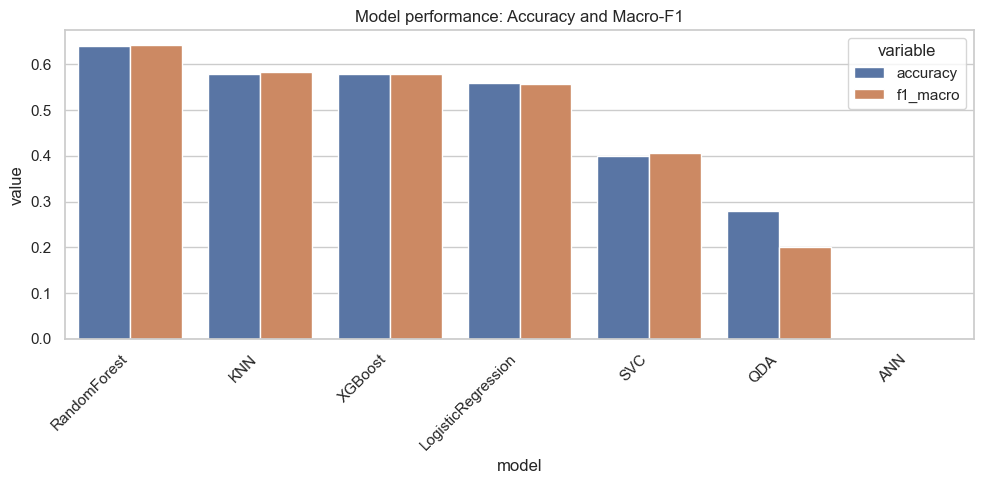

In [50]:
# Performance summary (accuracy + macro-F1 if available)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# collect models
models = {}
for name, info in (results.items() if 'results' in globals() else {}):
    model = info['model'] if isinstance(info, dict) and 'model' in info else info
    models[name] = model

rows = []
for name, model in models.items():
    # choose test set
    X_test_use = globals().get('X_test_scaled', globals().get('X_test'))
    y_test_use = globals().get('y_test')
    if X_test_use is None or y_test_use is None:
        continue
    try:
        y_pred = model.predict(X_test_use)
        acc = accuracy_score(y_test_use, y_pred)
        p = precision_score(y_test_use, y_pred, average='macro', zero_division=0)
        r = recall_score(y_test_use, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test_use, y_pred, average='macro', zero_division=0)
    except Exception:
        acc = np.nan; p = np.nan; r = np.nan; f1 = np.nan
    rows.append({'model': name, 'accuracy': acc, 'precision_macro': p, 'recall_macro': r, 'f1_macro': f1})

perf_df = pd.DataFrame(rows).sort_values('accuracy', ascending=False).reset_index(drop=True)
display(perf_df)

# bar chart
plt.figure(figsize=(10,5))
sns.barplot(data=perf_df.melt(id_vars='model', value_vars=['accuracy','f1_macro']),
            x='model', y='value', hue='variable')
plt.xticks(rotation=45, ha='right')
plt.title('Model performance: Accuracy and Macro-F1')
plt.tight_layout()
plt.show()

### Confusion matrix

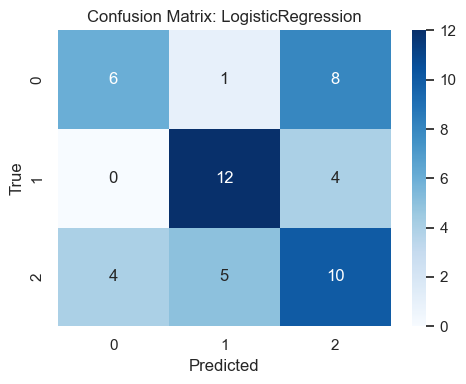

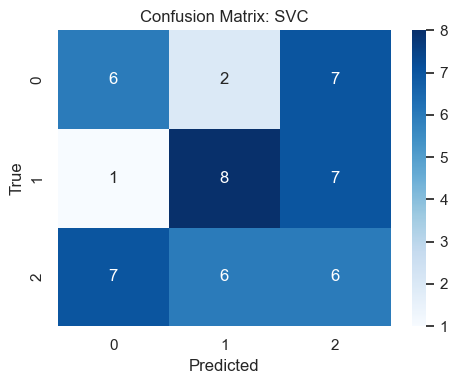

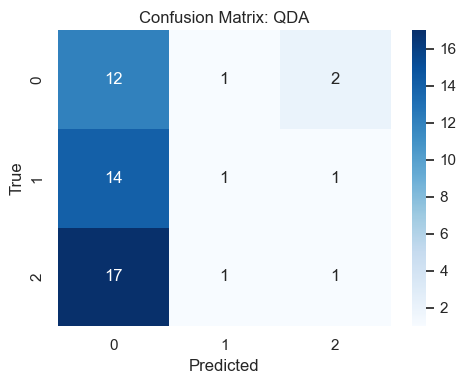

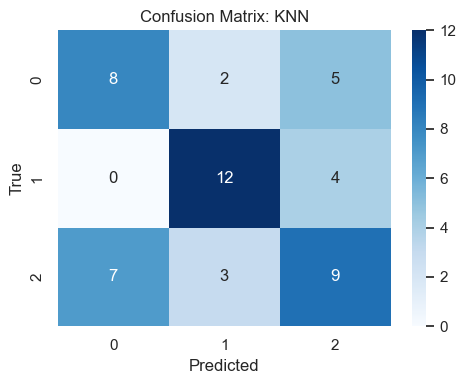

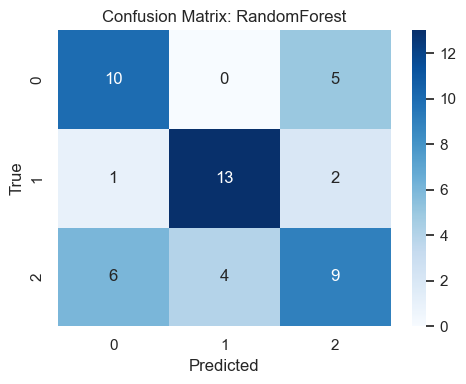

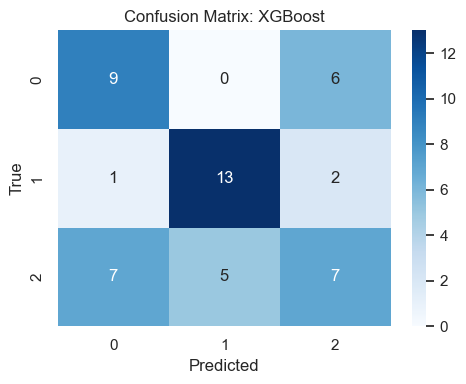

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Skipping ANN: Classification metrics can't handle a mix of multiclass and continuous-multioutput targets


In [51]:
# Confusion matrices
from sklearn.metrics import confusion_matrix
import numpy as np

X_test_use = globals().get('X_test_scaled', globals().get('X_test'))
y_test_use = globals().get('y_test')
if X_test_use is None or y_test_use is None:
    print("X_test / y_test not found in namespace.")
else:
    for name, model in models.items():
        try:
            y_pred = model.predict(X_test_use)
            cm = confusion_matrix(y_test_use, y_pred)
            plt.figure(figsize=(5,4))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            plt.title(f'Confusion Matrix: {name}')
            plt.xlabel('Predicted'); plt.ylabel('True')
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Skipping {name}: {e}")

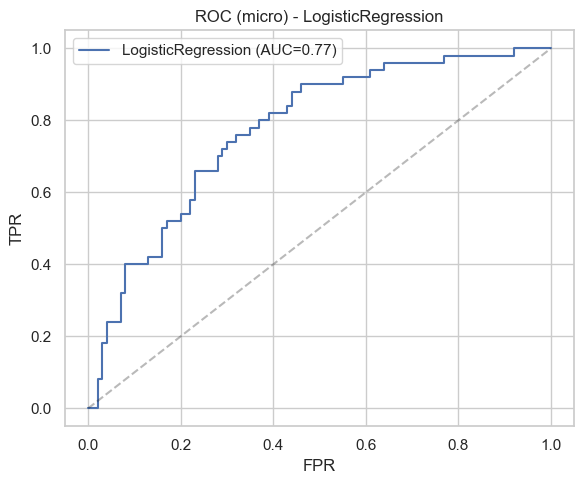

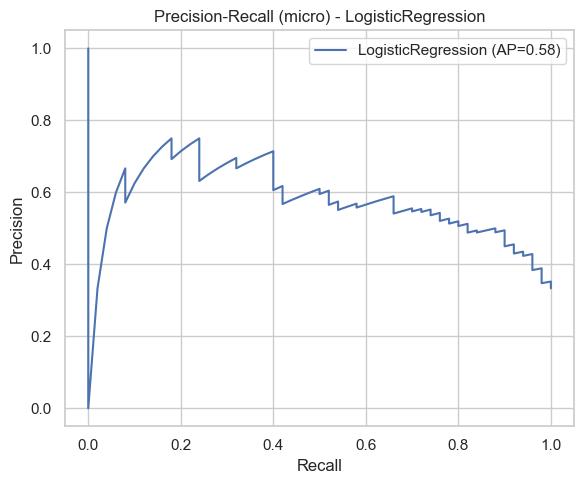

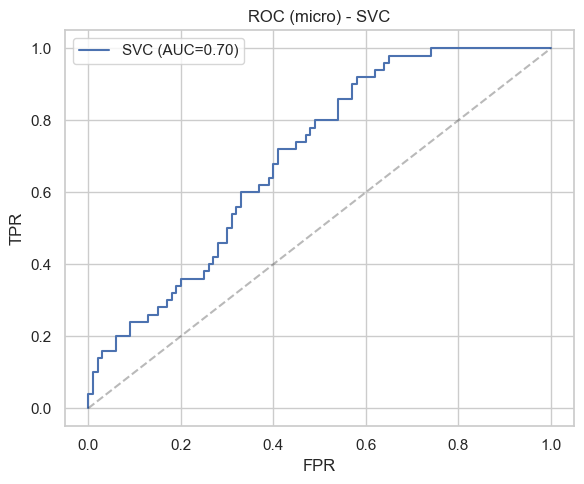

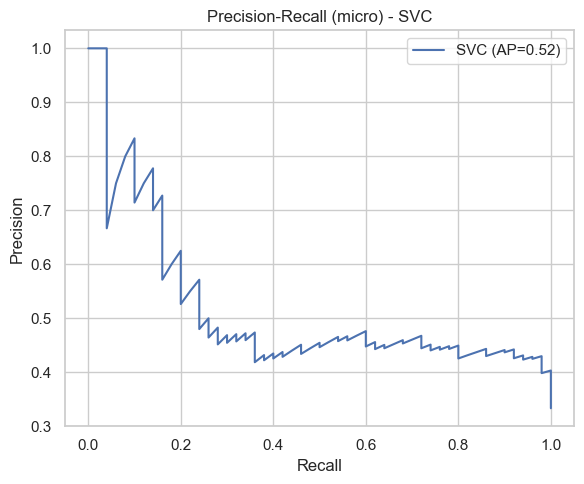

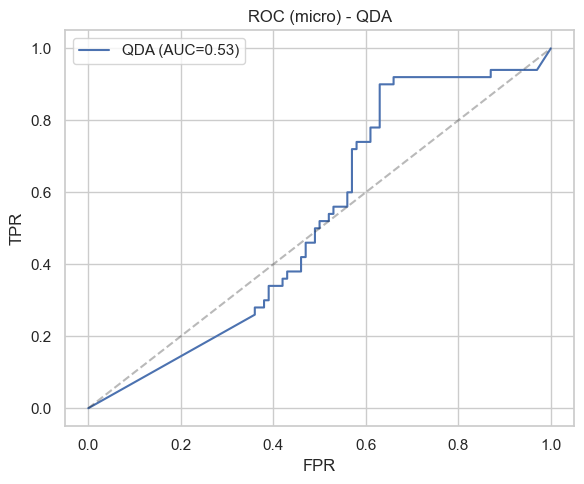

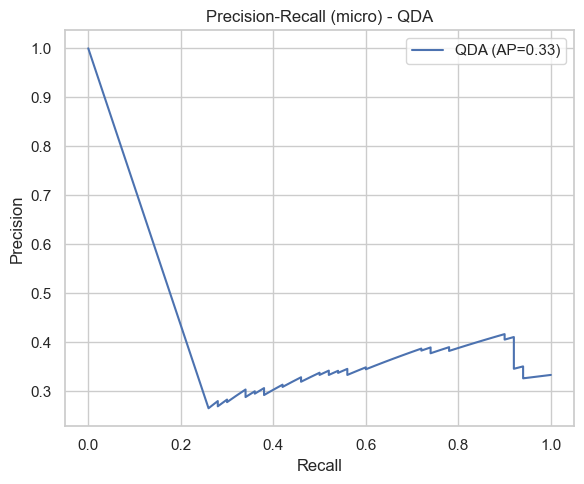

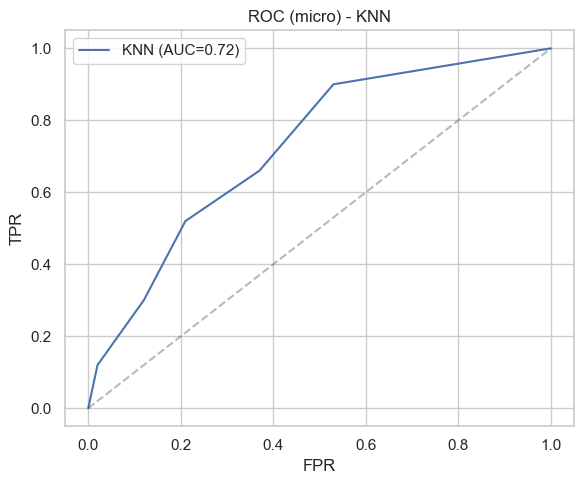

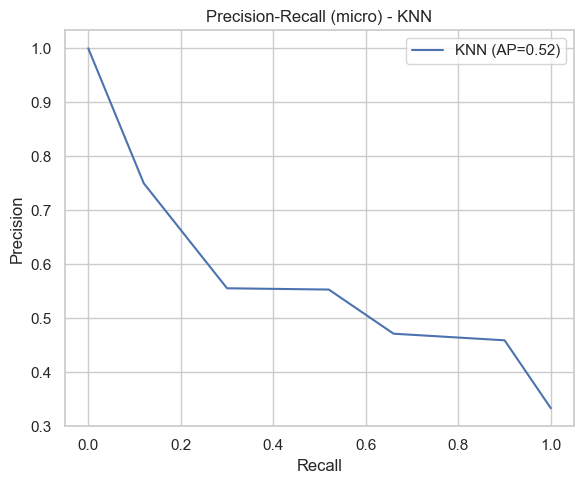

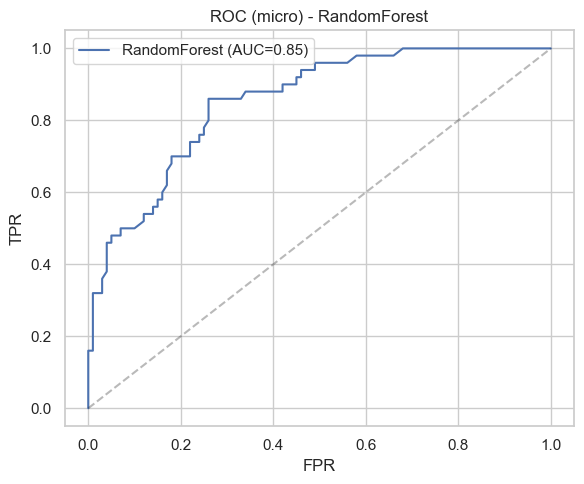

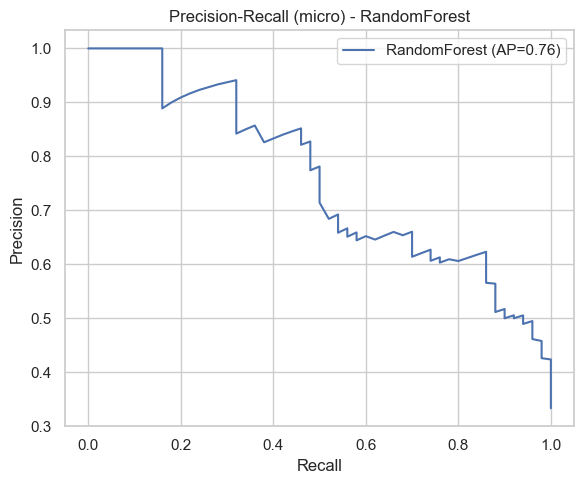

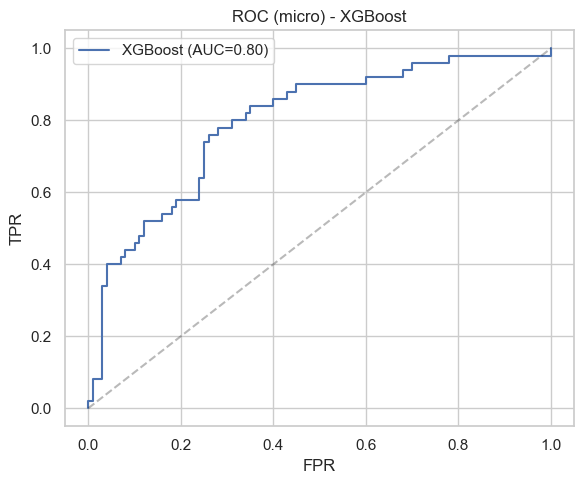

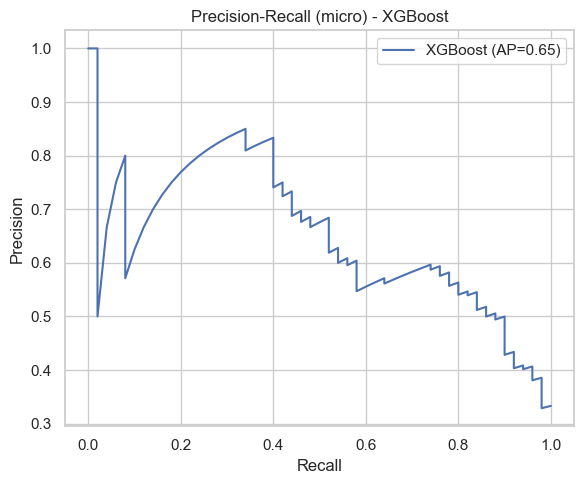

No prob/score for ANN, skipping ROC/PR.


In [52]:
# ROC & PR curves (multi-class micro-average). Requires predict_proba or decision_function.
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np

X_test_use = globals().get('X_test_scaled', globals().get('X_test'))
y_test_use = globals().get('y_test')
if X_test_use is None or y_test_use is None:
    print("X_test / y_test not found.")
else:
    classes = np.unique(y_test_use)
    y_bin = label_binarize(y_test_use, classes=classes)
    for name, model in models.items():
        try:
            if hasattr(model, 'predict_proba'):
                y_score = model.predict_proba(X_test_use)
            elif hasattr(model, 'decision_function'):
                y_score = model.decision_function(X_test_use)
            else:
                print(f"No prob/score for {name}, skipping ROC/PR.")
                continue
            # micro-average ROC
            fpr, tpr, _ = roc_curve(y_bin.ravel(), y_score.ravel())
            roc_auc = auc(fpr, tpr)
            plt.figure(figsize=(6,5))
            plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.2f})')
            plt.plot([0,1],[0,1],'k--', alpha=0.3)
            plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title(f'ROC (micro) - {name}')
            plt.legend(); plt.tight_layout(); plt.show()

            # PR curve (micro)
            precision, recall, _ = precision_recall_curve(y_bin.ravel(), y_score.ravel())
            ap = average_precision_score(y_bin, y_score, average='micro')
            plt.figure(figsize=(6,5))
            plt.plot(recall, precision, label=f'{name} (AP={ap:.2f})')
            plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title(f'Precision-Recall (micro) - {name}')
            plt.legend(); plt.tight_layout(); plt.show()
        except Exception as e:
            print(f"Error plotting ROC/PR for {name}: {e}")

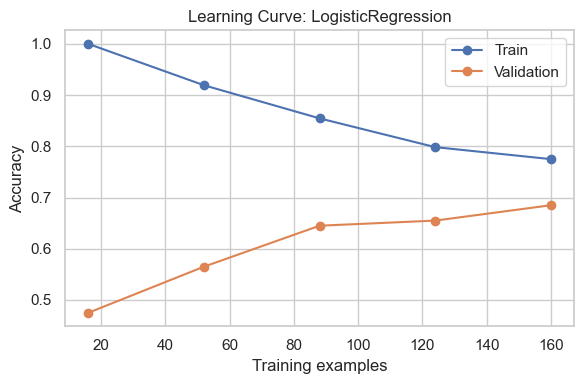

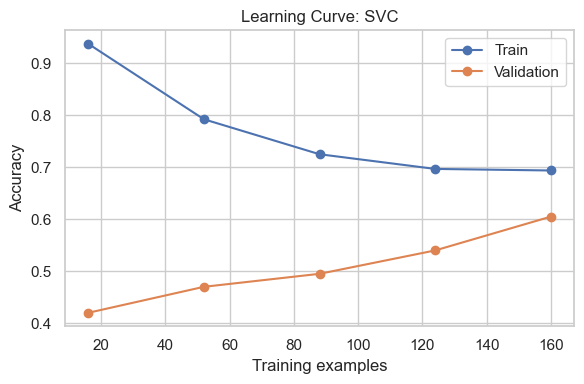

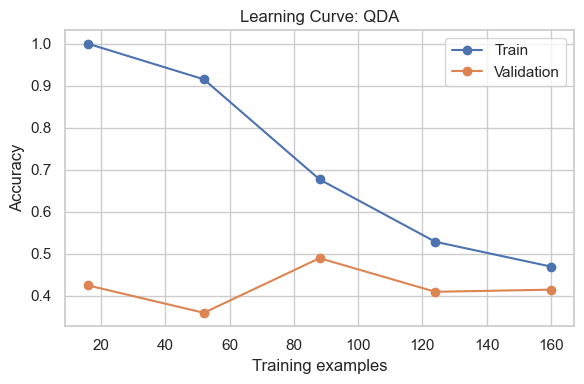

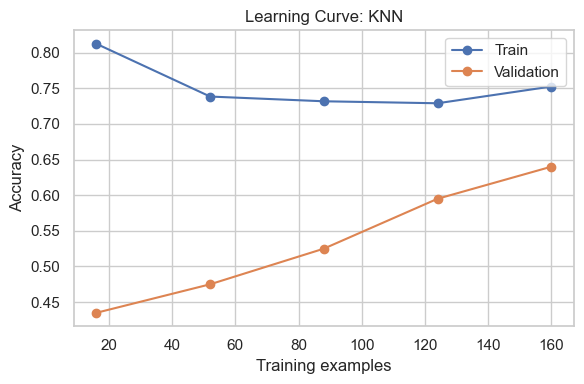

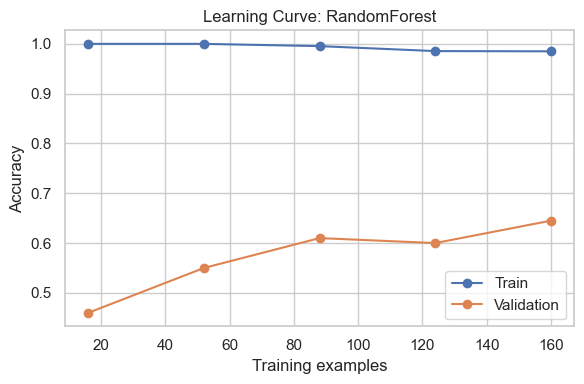

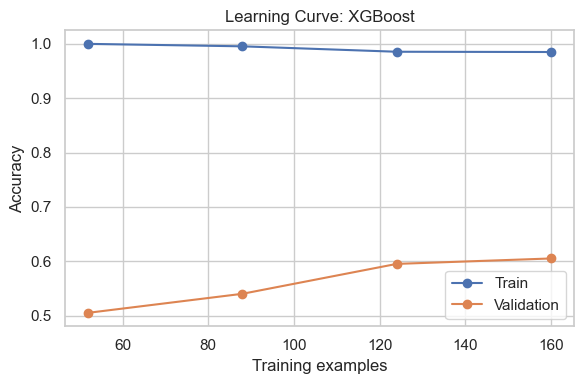

Learning curve failed for ANN: list index out of range


In [53]:
# Learning curves per model (may be slow)
from sklearn.model_selection import learning_curve
X_train_use = globals().get('X_train_scaled', globals().get('X_train'))
y_train_use = globals().get('y_train')
if X_train_use is None or y_train_use is None:
    print("X_train / y_train not found.")
else:
    for name, model in models.items():
        try:
            train_sizes, train_scores, val_scores = learning_curve(model, X_train_use, y_train_use, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1,1.0,5), scoring='accuracy')
            plt.figure(figsize=(6,4))
            plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train')
            plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation')
            plt.title(f'Learning Curve: {name}')
            plt.xlabel('Training examples'); plt.ylabel('Accuracy'); plt.legend(); plt.tight_layout(); plt.show()
        except Exception as e:
            print(f"Learning curve failed for {name}: {e}")

Skipping ANN: no `predict_proba` or `decision_function`.


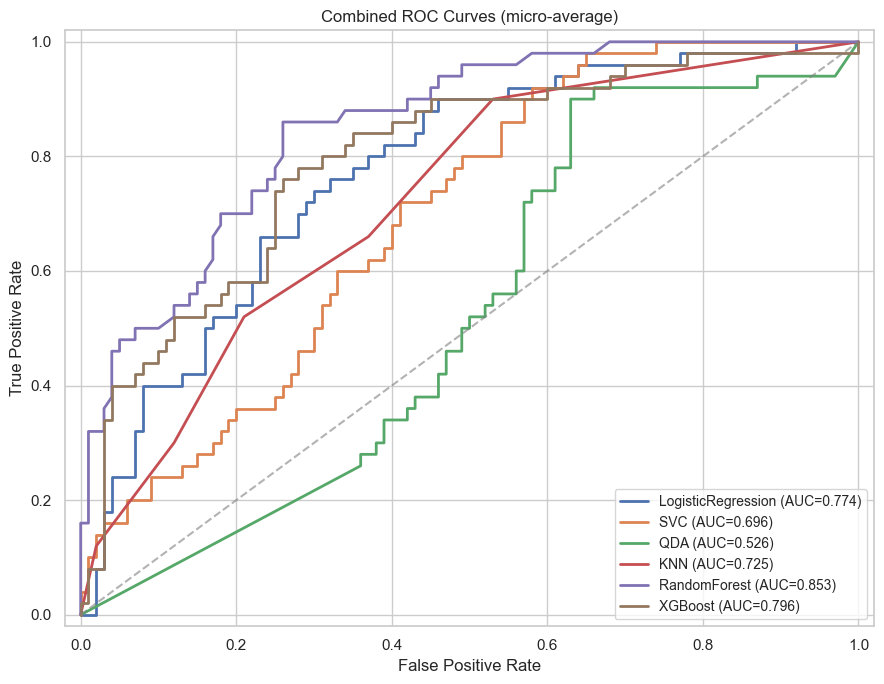

In [54]:
# Combined ROC curves (micro-average) for all models in `results`
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# collect models
models = {}
if 'results' in globals():
    for name, info in results.items():
        model = info['model'] if isinstance(info, dict) and 'model' in info else info
        models[name] = model
else:
    raise RuntimeError("`results` not found in namespace.")

# test data (prefer scaled if available)
X_test_use = globals().get('X_test_scaled', globals().get('X_test'))
y_test_use = globals().get('y_test')
if X_test_use is None or y_test_use is None:
    raise RuntimeError("`X_test` / `y_test` not found. Define them before running this cell.")

# binarize labels for multiclass micro-average
classes = np.unique(y_test_use)
y_bin = label_binarize(y_test_use, classes=classes)

plt.figure(figsize=(9,7))
sns.set_style("whitegrid")

for name, model in models.items():
    try:
        if hasattr(model, 'predict_proba'):
            y_score = model.predict_proba(X_test_use)
        elif hasattr(model, 'decision_function'):
            y_score = model.decision_function(X_test_use)
            if y_score.ndim == 1:
                y_score = np.vstack([1 - y_score, y_score]).T
        else:
            print(f"Skipping {name}: no `predict_proba` or `decision_function`.")
            continue

        fpr, tpr, _ = roc_curve(y_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc:.3f})")
    except Exception as e:
        print(f"Error for {name}: {e}")

plt.plot([0,1], [0,1], linestyle='--', color='gray', alpha=0.6)
plt.xlim([-0.02,1.02]); plt.ylim([-0.02,1.02])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Combined ROC Curves (micro-average)')
plt.legend(loc='lower right', fontsize='small')
plt.tight_layout()
plt.show()

## Feature Important

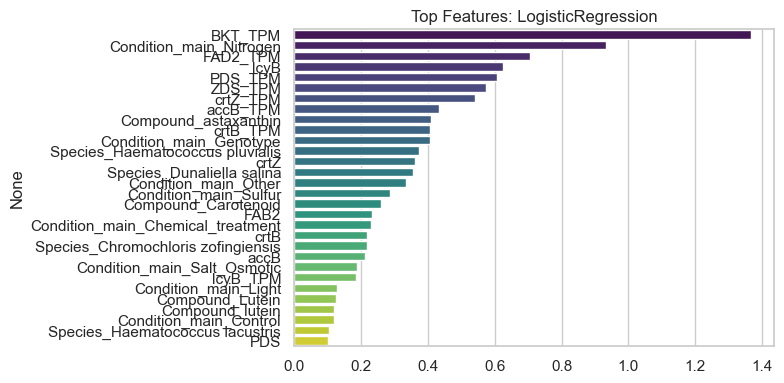

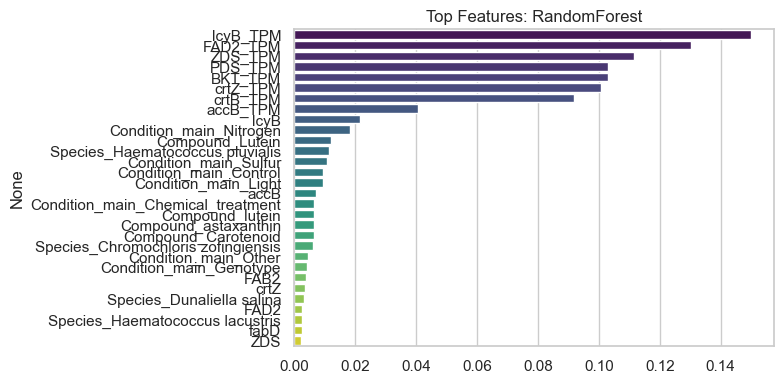

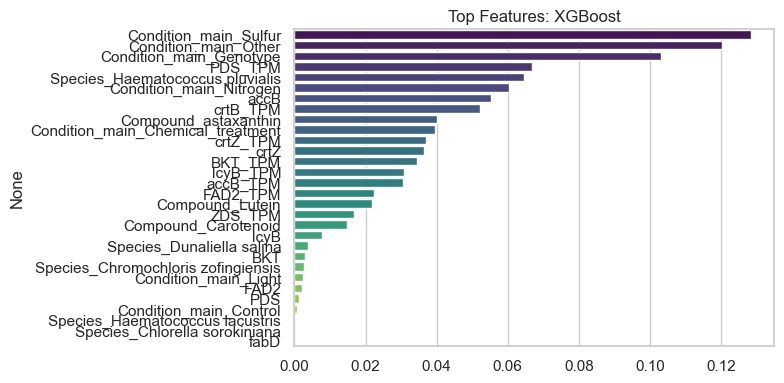

In [55]:
# Feature importances
feature_names = None
if 'X_train' in globals() and hasattr(X_train, 'columns'):
    feature_names = X_train.columns
elif 'X_encoded' in globals() and hasattr(X_encoded, 'columns'):
    feature_names = X_encoded.columns

for name, model in models.items():
    try:
        if hasattr(model, 'feature_importances_'):
            imp = model.feature_importances_
        elif hasattr(model, 'coef_'):
            imp = np.abs(model.coef_).mean(axis=0) if model.coef_.ndim>1 else np.abs(model.coef_)
        else:
            continue
        if feature_names is None:
            feature_names = [f'F{i}' for i in range(len(imp))]
        imp_df = pd.Series(imp, index=feature_names).sort_values(ascending=False).head(30)
        plt.figure(figsize=(8,4))
        sns.barplot(x=imp_df.values, y=imp_df.index, palette='viridis')
        plt.title(f'Top Features: {name}')
        plt.tight_layout(); plt.show()
    except Exception as e:
        print(f"Feature importances not available for {name}: {e}")

## Old model code

In [85]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Dictionary to store models and their performance
imputation_models = {}

# 1. Logistic Regression
print("=" * 50)
print("Training Logistic Regression")
print("=" * 50)
lr = LogisticRegression(random_state=42, max_iter=1000)
lr_scores = cross_val_score(lr, X_labeled_scaled, y_labeled_encoded, cv=5)
print(f"Cross-validation scores: {lr_scores}")
print(f"Mean CV Accuracy: {lr_scores.mean():.4f} (+/- {lr_scores.std():.4f})")
lr.fit(X_labeled_scaled, y_labeled_encoded)
imputation_models['Logistic Regression'] = lr

# 2. K-Nearest Neighbors
print("\n" + "=" * 50)
print("Training K-Nearest Neighbors")
print("=" * 50)
knn = KNeighborsClassifier(n_neighbors=5)
knn_scores = cross_val_score(knn, X_labeled_scaled, y_labeled_encoded, cv=5)
print(f"Cross-validation scores: {knn_scores}")
print(f"Mean CV Accuracy: {knn_scores.mean():.4f} (+/- {knn_scores.std():.4f})")
knn.fit(X_labeled_scaled, y_labeled_encoded)
imputation_models['KNN'] = knn

# 3. Random Forest
print("\n" + "=" * 50)
print("Training Random Forest")
print("=" * 50)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_scores = cross_val_score(rf, X_labeled_scaled, y_labeled_encoded, cv=5)
print(f"Cross-validation scores: {rf_scores}")
print(f"Mean CV Accuracy: {rf_scores.mean():.4f} (+/- {rf_scores.std():.4f})")
rf.fit(X_labeled_scaled, y_labeled_encoded)
imputation_models['Random Forest'] = rf

# 4. XGBoost
print("\n" + "=" * 50)
print("Training XGBoost")
print("=" * 50)
xgb = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_scores = cross_val_score(xgb, X_labeled_scaled, y_labeled_encoded, cv=5)
print(f"Cross-validation scores: {xgb_scores}")
print(f"Mean CV Accuracy: {xgb_scores.mean():.4f} (+/- {xgb_scores.std():.4f})")
xgb.fit(X_labeled_scaled, y_labeled_encoded)
imputation_models['XGBoost'] = xgb

# Summary of model performance
print("\n" + "=" * 50)
print("Model Performance Summary")
print("=" * 50)
model_scores = {
    'Logistic Regression': lr_scores.mean(),
    'KNN': knn_scores.mean(),
    'Random Forest': rf_scores.mean(),
    'XGBoost': xgb_scores.mean()
}
for model_name, score in sorted(model_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name}: {score:.4f}")

Training Logistic Regression


NameError: name 'X_labeled_scaled' is not defined

#### Tune Logistic Regression

In [ ]:
print("=" * 60)
print("TUNING LOGISTIC REGRESSION")
print("=" * 60)

# Define hyperparameter grid
lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse regularization strength
    'penalty': ['l2'],  # L2 regularization
    'solver': ['lbfgs', 'liblinear'],  # Solver algorithms
    'max_iter': [1000, 5000, 10000]
}

# GridSearchCV for exhaustive search
lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\nPerforming GridSearchCV for Logistic Regression...")
lr_grid.fit(X_labeled_scaled, y_labeled_encoded)

print(f"\nBest parameters: {lr_grid.best_params_}")
print(f"Best CV Accuracy: {lr_grid.best_score_:.4f}")

# Get best model
lr_best = lr_grid.best_estimator_
lr_best_pred = lr_best.predict(X_labeled_scaled)
print(f"Training Accuracy: {accuracy_score(y_labeled_encoded, lr_best_pred):.4f}")

# Store best model
imputation_models['LR_tuned'] = lr_best
model_scores['LR_tuned'] = lr_grid.best_score_

TUNING LOGISTIC REGRESSION

Performing GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Accuracy: 0.6457
Training Accuracy: 0.6914


#### Tune K-Nearest Neighbors

In [ ]:
print("\n" + "=" * 60)
print("TUNING K-NEAREST NEIGHBORS")
print("=" * 60)

# Define hyperparameter grid
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],  # Number of neighbors
    'weights': ['uniform', 'distance'],  # Weight function
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],  # Algorithm
    'p': [1, 2]  # Minkowski distance power (1=Manhattan, 2=Euclidean)
}

# RandomizedSearchCV for faster tuning (KNN has many params)
knn_random = RandomizedSearchCV(
    KNeighborsClassifier(),
    knn_params,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("\nPerforming RandomizedSearchCV for KNN...")
knn_random.fit(X_labeled_scaled, y_labeled_encoded)

print(f"\nBest parameters: {knn_random.best_params_}")
print(f"Best CV Accuracy: {knn_random.best_score_:.4f}")

# Get best model
knn_best = knn_random.best_estimator_
knn_best_pred = knn_best.predict(X_labeled_scaled)
print(f"Training Accuracy: {accuracy_score(y_labeled_encoded, knn_best_pred):.4f}")

# Store best model
imputation_models['KNN_tuned'] = knn_best
model_scores['KNN_tuned'] = knn_random.best_score_


TUNING K-NEAREST NEIGHBORS

Performing RandomizedSearchCV for KNN...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters: {'weights': 'uniform', 'p': 1, 'n_neighbors': 15, 'algorithm': 'kd_tree'}
Best CV Accuracy: 0.5657
Training Accuracy: 0.7429


#### Tune Random Forest

In [ ]:
print("\n" + "=" * 60)
print("TUNING RANDOM FOREST")
print("=" * 60)

# Define hyperparameter grid
rf_params = {
    'n_estimators': [50, 100, 200, 300],  # Number of trees
    'max_depth': [5, 10, 15, 20, None],  # Max depth of trees
    'min_samples_split': [2, 5, 10, 20],  # Min samples to split
    'min_samples_leaf': [1, 2, 4, 8],  # Min samples in leaf
    'max_features': ['sqrt', 'log2'],  # Features per split
    'bootstrap': [True, False]  # Use bootstrap
}

# RandomizedSearchCV for efficiency
rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("\nPerforming RandomizedSearchCV for Random Forest...")
rf_random.fit(X_labeled_scaled, y_labeled_encoded)

print(f"\nBest parameters: {rf_random.best_params_}")
print(f"Best CV Accuracy: {rf_random.best_score_:.4f}")

# Get best model
rf_best = rf_random.best_estimator_
rf_best_pred = rf_best.predict(X_labeled_scaled)
print(f"Training Accuracy: {accuracy_score(y_labeled_encoded, rf_best_pred):.4f}")

# Feature importance
print("\nFeature Importance (Top 10):")
feature_importance = pd.DataFrame({
    'Feature': X_labeled_encoded.columns,
    'Importance': rf_best.feature_importances_
}).sort_values('Importance', ascending=False)
print(feature_importance.head(10))

# Store best model
imputation_models['RF_tuned'] = rf_best
model_scores['RF_tuned'] = rf_random.best_score_


TUNING RANDOM FOREST

Performing RandomizedSearchCV for Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': True}
Best CV Accuracy: 0.6571
Training Accuracy: 0.8514

Feature Importance (Top 10):
                              Feature  Importance
2                          TPM of BKT    0.263147
3                       TPM of CrtR-b    0.240393
6                Condition_main_Light    0.155678
1                              CrtR-b    0.076202
7              Condition_main_Light\n    0.055435
4   Condition_main_Chemical_treatment    0.044774
12                Compound_Carotenoid    0.034485
0                                 BKT    0.033425
14               Compound_astaxanthin    0.030727
8             Condition_main_Nitrogen    0.030054


#### Tune XGBoost

In [ ]:
print("\n" + "=" * 60)
print("TUNING XGBOOST")
print("=" * 60)

# Two-stage tuning for XGBoost (recommended approach)
# Stage 1: Tune tree-specific parameters
xgb_params_1 = {
    'max_depth': [3, 5, 7, 9],  # Tree depth
    'min_child_weight': [1, 3, 5, 7],  # Min child weight
    'subsample': [0.6, 0.8, 1.0],  # Row sampling
    'colsample_bytree': [0.6, 0.8, 1.0]  # Column sampling
}

print("\nStage 1: Tuning tree parameters...")
xgb_random_1 = RandomizedSearchCV(
    XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss'),
    xgb_params_1,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_random_1.fit(X_labeled_scaled, y_labeled_encoded)
print(f"Best tree parameters: {xgb_random_1.best_params_}")
print(f"Best CV Accuracy: {xgb_random_1.best_score_:.4f}")

# Stage 2: Tune boosting parameters with best tree params
best_tree_params = xgb_random_1.best_params_

xgb_params_2 = {
    'n_estimators': [100, 200, 300, 500],  # Number of boosting rounds
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2],  # Learning rate
    'gamma': [0, 0.1, 0.5, 1.0]  # Min loss reduction
}

print("\nStage 2: Tuning boosting parameters...")
xgb_random_2 = RandomizedSearchCV(
    XGBClassifier(
        max_depth=best_tree_params['max_depth'],
        min_child_weight=best_tree_params['min_child_weight'],
        subsample=best_tree_params['subsample'],
        colsample_bytree=best_tree_params['colsample_bytree'],
        random_state=42,
        eval_metric='mlogloss'
    ),
    xgb_params_2,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_random_2.fit(X_labeled_scaled, y_labeled_encoded)
print(f"\nBest boosting parameters: {xgb_random_2.best_params_}")
print(f"Best CV Accuracy: {xgb_random_2.best_score_:.4f}")

# Get best XGBoost model
xgb_best = xgb_random_2.best_estimator_
xgb_best_pred = xgb_best.predict(X_labeled_scaled)
print(f"Training Accuracy: {accuracy_score(y_labeled_encoded, xgb_best_pred):.4f}")

# Feature importance
print("\nFeature Importance (Top 10):")
xgb_importance = pd.DataFrame({
    'Feature': X_labeled_encoded.columns,
    'Importance': xgb_best.feature_importances_
}).sort_values('Importance', ascending=False)
print(xgb_importance.head(10))

# Store best model
imputation_models['XGB_tuned'] = xgb_best
model_scores['XGB_tuned'] = xgb_random_2.best_score_


TUNING XGBOOST

Stage 1: Tuning tree parameters...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best tree parameters: {'subsample': 0.6, 'min_child_weight': 3, 'max_depth': 7, 'colsample_bytree': 0.6}
Best CV Accuracy: 0.6629

Stage 2: Tuning boosting parameters...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best boosting parameters: {'n_estimators': 100, 'learning_rate': 0.01, 'gamma': 0}
Best CV Accuracy: 0.6514
Training Accuracy: 0.8229

Feature Importance (Top 10):
                              Feature  Importance
6                Condition_main_Light    0.211254
2                          TPM of BKT    0.118518
12                Compound_Carotenoid    0.108747
3                       TPM of CrtR-b    0.096739
1                              CrtR-b    0.094204
0                                 BKT    0.094063
4   Condition_main_Chemical_treatment    0.077700
14               Compound_astaxanthin    0.072615
7              Condition_main_Light\n  

In [ ]:
# make Series so pandas aligns by model name
original_sr = pd.Series(original_scores)
tuned_sr = pd.Series(tuned_scores)

comparison_df = pd.concat([original_sr, tuned_sr], axis=1)
comparison_df.columns = ['Original', 'Tuned']

comparison_df['Improvement'] = comparison_df['Tuned'] - comparison_df['Original']
comparison_df['Improvement %'] = (comparison_df['Improvement'] /
                                  comparison_df['Original'].replace(0, np.nan) * 100).fillna(0)

print(comparison_df)
print(f"\nBest Original Model: {max(original_scores, key=original_scores.get)} ({max(original_scores.values()):.4f})")
print(f"Best Tuned Model: {max(tuned_scores, key=tuned_scores.get)} ({max(tuned_scores.values()):.4f})")

                     Original     Tuned  Improvement  Improvement %
Logistic Regression  0.497143  0.645714     0.148571      29.885057
KNN                  0.508571  0.565714     0.057143      11.235955
Random Forest        0.571429  0.657143     0.085714      15.000000
XGBoost              0.542857  0.651429     0.108571      20.000000

Best Original Model: Random Forest (0.5714)
Best Tuned Model: Random Forest (0.6571)


In [ ]:
# Use the best model (choose the one with highest CV score)
best_model_name = max(model_scores, key=model_scores.get)
best_model = imputation_models[best_model_name]

print(f"Using {best_model_name} for imputation (Accuracy: {model_scores[best_model_name]:.4f})")

# Predict missing labels
y_unlabeled_predicted_encoded = best_model.predict(X_unlabeled_scaled)

# Decode predictions back to original label names
y_unlabeled_predicted = label_encoder.inverse_transform(y_unlabeled_predicted_encoded)

print(f"\nPredicted labels for missing values:")
print(f"Distribution of imputed labels:")
unique, counts = np.unique(y_unlabeled_predicted, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {label}: {count}")

Using RF_tuned for imputation (Accuracy: 0.6571)

Predicted labels for missing values:
Distribution of imputed labels:
  High: 1
  Low: 44


Label distribution comparison:

Before imputation (labeled data only):
Label
Low       0.371429
Medium    0.314286
High      0.314286
Name: proportion, dtype: float64

After imputation (full dataset):
Label
Low       0.495455
High      0.254545
Medium    0.250000
Name: proportion, dtype: float64


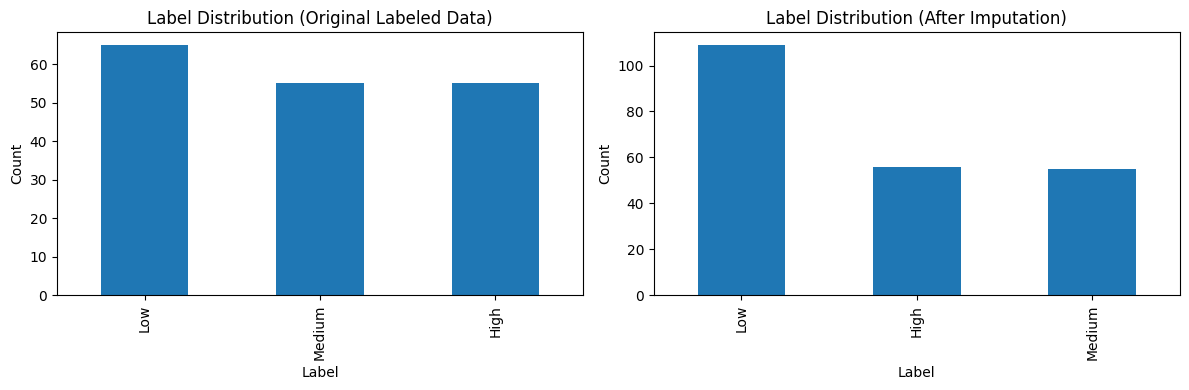

In [ ]:
# Compare distributions before and after
print("Label distribution comparison:")
print("\nBefore imputation (labeled data only):")
print(labeled_df['Label'].value_counts(normalize=True))
print("\nAfter imputation (full dataset):")
print(df_imputed['Label'].value_counts(normalize=True))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original labeled data
labeled_df['Label'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Label Distribution (Original Labeled Data)')
axes[0].set_ylabel('Count')

# After imputation
df_imputed['Label'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Label Distribution (After Imputation)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
df_imputed.shape

(220, 10)

In [ ]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 220 entries, 0 to 223
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Species         220 non-null    object 
 1   Strain          202 non-null    object 
 2   Bioproject      220 non-null    object 
 3   Condition_main  220 non-null    object 
 4   Compound        220 non-null    object 
 5   Label           220 non-null    object 
 6   BKT             220 non-null    float64
 7   CrtR-b          220 non-null    float64
 8   TPM of BKT      220 non-null    float64
 9   TPM of CrtR-b   220 non-null    float64
dtypes: float64(4), object(6)
memory usage: 27.0+ KB


In [ ]:
target_col = 'Label'
cols_to_drop = ['Species', 'Strain', 'Bioproject']  # drop identifiers/non-features

In [ ]:
X = df_imputed.drop(columns=cols_to_drop + [target_col])
y = df_imputed[target_col]

In [ ]:
# encode target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [ ]:
# one-hot encode categorical features (same approach as before)
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [ ]:
#Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [ ]:
#Fearure Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}, X_test shape: {X_test_scaled.shape}")

X_train shape: (140, 15), X_test shape: (35, 15)


In [ ]:
#Collect Models results
results = {}